# NIRF Ranking 2025 - Exploratory Data Analysis
Exploring India's Top 100 Institutions

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv('/kaggle/input/top-100-indian-universities-dataset/NIRF Ranking 2025.csv')
print(f"Dataset Shape: {df.shape}")
df.head(10)

Dataset Shape: (100, 11)


,Institute ID,Institute Name,TLR,RPC,GO,OI,PERCEPTION,City,State,Score,Rank
0,IR-O-U-0456,Indian Institute of Technology Madras,90.58,88.02,87.01,63.34,100.00,Chennai,Tamil Nadu,87.31,1
1,IR-O-U-0220,Indian Institute of Science,86.47,88.16,83.69,60.29,98.41,Bengaluru,Karnataka,85.00,2
2,IR-O-U-0306,Indian Institute of Technology Bombay,83.79,83.05,86.04,60.13,83.35,Mumbai,Maharashtra,81.62,3
3,IR-O-I-1074,Indian Institute of Technology Delhi,80.52,86.67,74.71,63.54,92.23,New Delhi,Delhi,80.67,4
4,IR-O-I-1075,Indian Institute of Technology Kanpur,86.36,72.12,82.01,60.38,72.56,Kanpur,Uttar Pradesh,77.25,5
5,IR-O-U-0573,Indian Institute of Technology Kharagpur,77.73,71.21,81.52,60.63,69.51,Kharagpur,West Bengal,73.99,6
6,IR-O-U-0560,Indian Institute of Technology Roorkee,73.06,72.05,82.90,64.95,51.24,Roorkee,Uttarakhand,71.73,7
7,IR-O-N-15,"All India Institute of Medical Sciences, Delhi",75.64,65.06,68.65,70.92,75.40,New Delhi,Delhi,70.57,8
8,IR-O-U-0109,Jawaharlal Nehru University,75.53,45.59,99.93,78.82,54.13,New Delhi,Delhi,69.62,9
9,IR-O-U-0500,Banaras Hindu University,76.41,51.17,95.42,65.95,47.63,Varanasi,Uttar Pradesh,68.71,10


## 2. Data Overview

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Institute ID    100 non-null    object 
 1   Institute Name  100 non-null    object 
 2   TLR             100 non-null    float64
 3   RPC             100 non-null    float64
 4   GO              100 non-null    float64
 5   OI              100 non-null    float64
 6   PERCEPTION      100 non-null    float64
 7   City            100 non-null    object 
 8   State           100 non-null    object 
 9   Score           100 non-null    float64
 10  Rank            100 non-null    int64  
dtypes: float64(6), int64(1), object(4)
memory usage: 8.7+ KB


In [4]:
df.describe()

,TLR,RPC,GO,OI,PERCEPTION,Score,Rank
count,100.00000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,69.22090,44.029700,74.810600,64.003500,24.236200,57.761200,50.480000
std,7.39369,14.729507,9.432211,7.526192,21.292134,8.175946,29.014618
min,51.46000,18.820000,52.520000,50.160000,0.410000,49.040000,1.000000
25%,63.35250,34.717500,69.262500,58.932500,10.020000,51.982500,25.750000
50%,70.40000,41.505000,73.430000,64.035000,18.480000,55.350000,50.500000
75%,73.75750,51.425000,80.627500,68.955000,27.775000,60.492500,75.250000
max,90.58000,88.160000,99.930000,83.830000,100.000000,87.310000,100.000000


In [5]:
# Missing values
df.isnull().sum()

Institute ID      0
Institute Name    0
TLR               0
RPC               0
GO                0
OI                0
PERCEPTION        0
City              0
State             0
Score             0
Rank              0
dtype: int64

## 3. Score Parameters Analysis
NIRF uses 5 parameters: TLR, RPC, GO, OI, PERCEPTION

In [6]:
# Score parameters stats
score_cols = ['TLR', 'RPC', 'GO', 'OI', 'PERCEPTION']
df[score_cols].describe()

,TLR,RPC,GO,OI,PERCEPTION
count,100.00000,100.000000,100.000000,100.000000,100.000000
mean,69.22090,44.029700,74.810600,64.003500,24.236200
std,7.39369,14.729507,9.432211,7.526192,21.292134
min,51.46000,18.820000,52.520000,50.160000,0.410000
25%,63.35250,34.717500,69.262500,58.932500,10.020000
50%,70.40000,41.505000,73.430000,64.035000,18.480000
75%,73.75750,51.425000,80.627500,68.955000,27.775000
max,90.58000,88.160000,99.930000,83.830000,100.000000


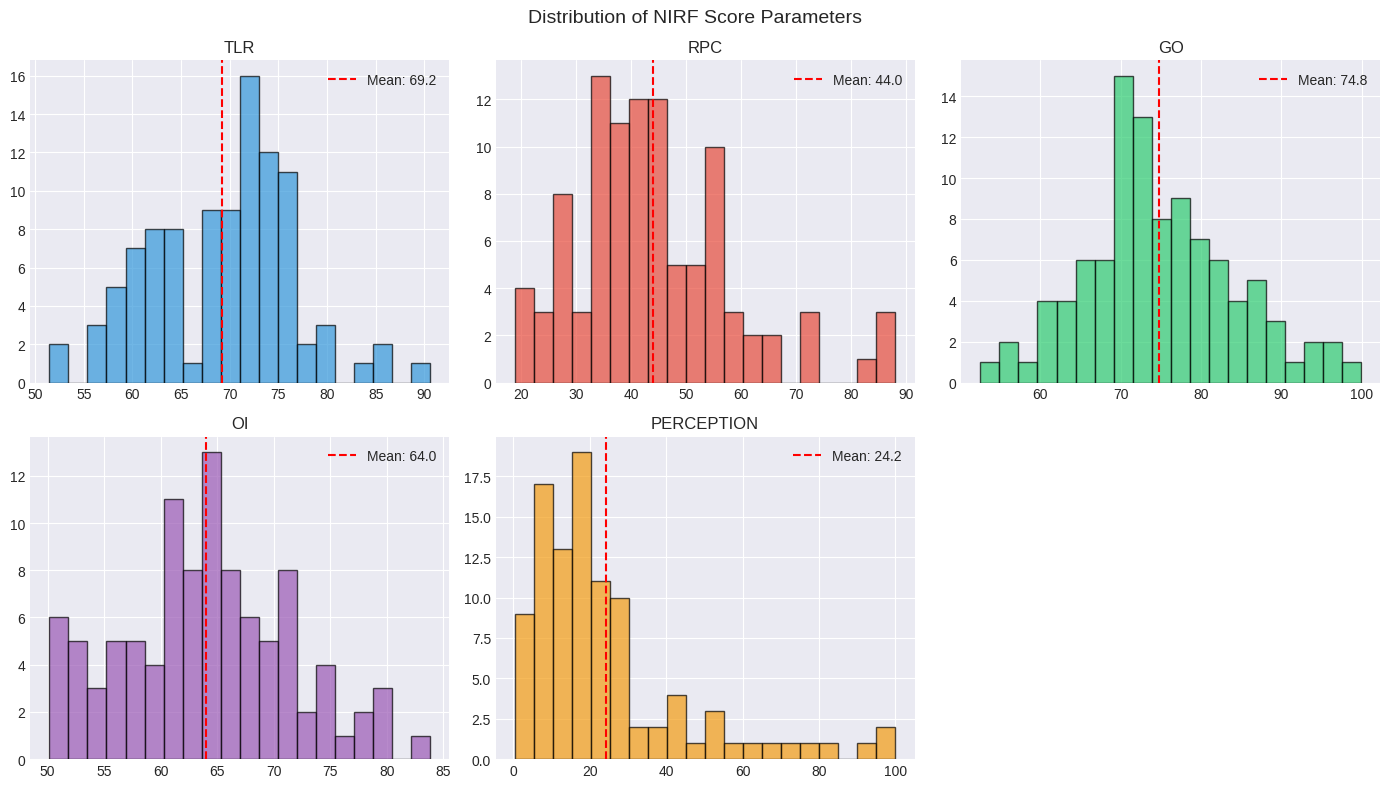

In [7]:
# Distribution of each parameter
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
colors = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6', '#f39c12']

for i, col in enumerate(score_cols):
    axes[i].hist(df[col], bins=20, color=colors[i], edgecolor='black', alpha=0.7)
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', label=f'Mean: {df[col].mean():.1f}')
    axes[i].set_title(col)
    axes[i].legend()

axes[-1].axis('off')
plt.suptitle('Distribution of NIRF Score Parameters', fontsize=14)
plt.tight_layout()
plt.show()

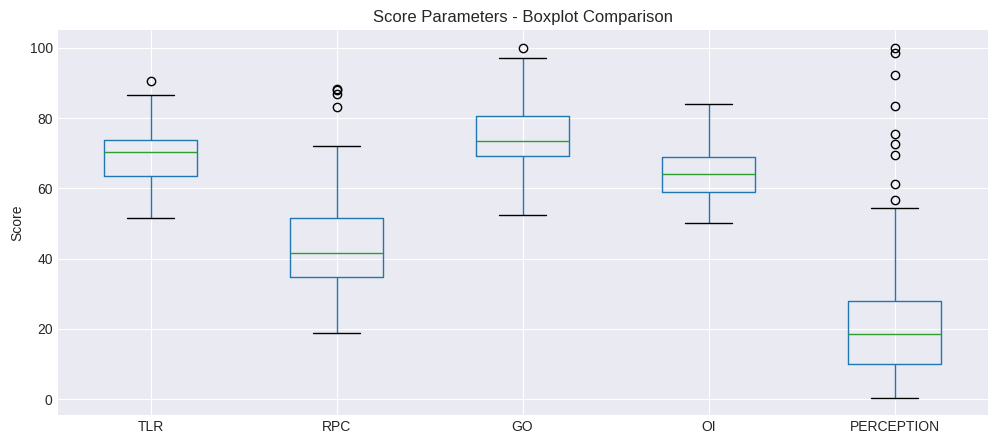

In [8]:
# Boxplot for all parameters
plt.figure(figsize=(12, 5))
df[score_cols].boxplot()
plt.title('Score Parameters - Boxplot Comparison')
plt.ylabel('Score')
plt.show()

## 4. Correlation Analysis

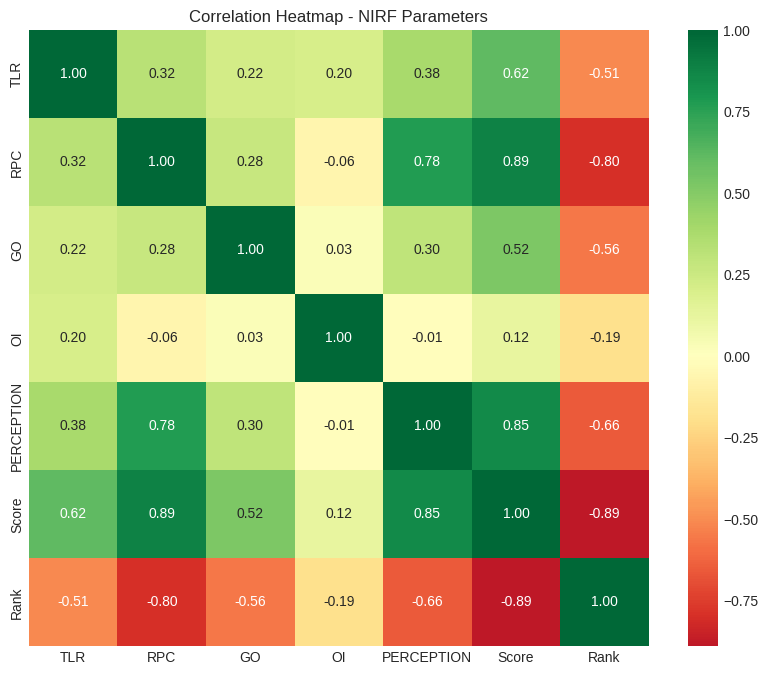

In [9]:
# Correlation between parameters and overall score
corr_cols = score_cols + ['Score', 'Rank']

plt.figure(figsize=(10, 8))
sns.heatmap(df[corr_cols].corr(), annot=True, cmap='RdYlGn', center=0, fmt='.2f')
plt.title('Correlation Heatmap - NIRF Parameters')
plt.show()

In [10]:
# Which parameter correlates most with overall Score?
score_corr = df[score_cols].corrwith(df['Score']).sort_values(ascending=False)
print("Correlation with Overall Score:")
print(score_corr)

Correlation with Overall Score:
RPC           0.888099
PERCEPTION    0.853034
TLR           0.615554
GO            0.521358
OI            0.116026
dtype: float64


## 5. State-wise Analysis

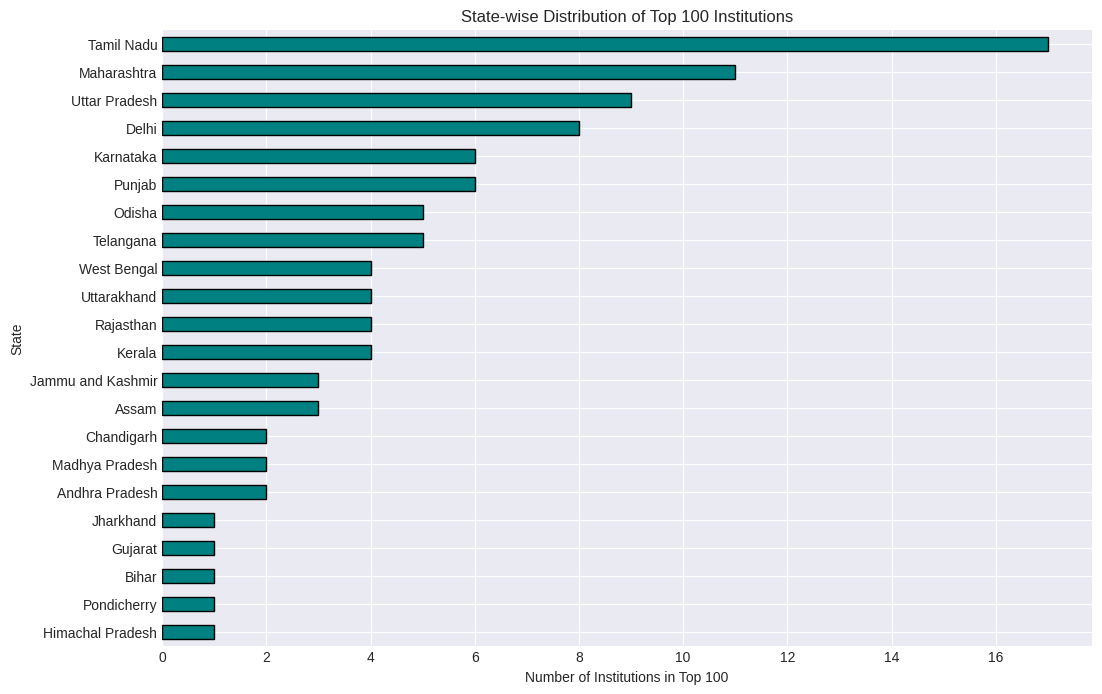

In [11]:
# Number of institutions per state
state_counts = df['State'].value_counts()

plt.figure(figsize=(12, 8))
state_counts.plot(kind='barh', color='teal', edgecolor='black')
plt.xlabel('Number of Institutions in Top 100')
plt.title('State-wise Distribution of Top 100 Institutions')
plt.gca().invert_yaxis()
plt.show()

In [12]:
# Top 5 states by count
print("Top 5 States with Most Institutions:")
print(state_counts.head())

Top 5 States with Most Institutions:
State
Tamil Nadu       17
Maharashtra      11
Uttar Pradesh     9
Delhi             8
Karnataka         6
Name: count, dtype: int64


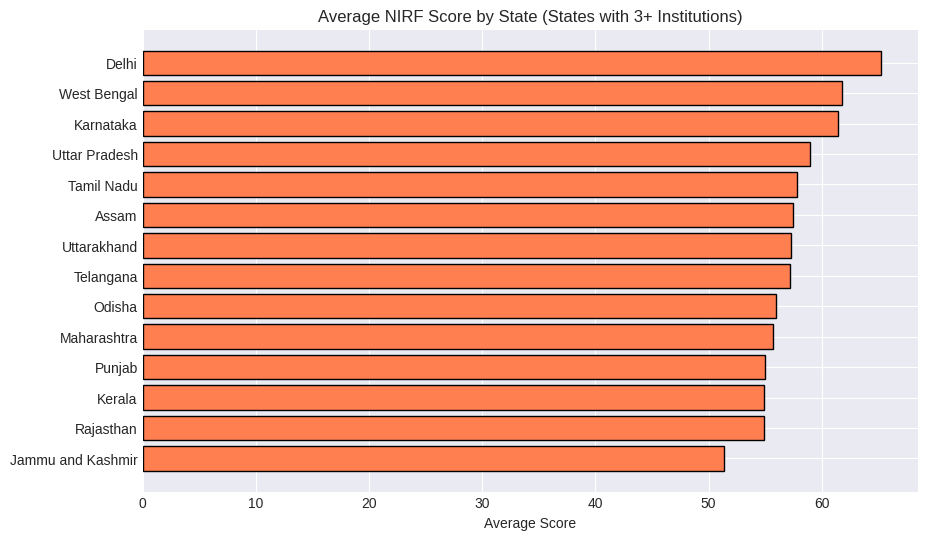

In [13]:
# Average score by state (states with 3+ institutions)
state_avg = df.groupby('State').agg({
    'Score': 'mean',
    'Institute Name': 'count'
}).rename(columns={'Institute Name': 'Count'})

state_avg = state_avg[state_avg['Count'] >= 3].sort_values('Score', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(state_avg.index, state_avg['Score'], color='coral', edgecolor='black')
plt.xlabel('Average Score')
plt.title('Average NIRF Score by State (States with 3+ Institutions)')
plt.gca().invert_yaxis()
plt.show()

## 6. Top 10 Institutions Deep Dive

In [14]:
top10 = df.head(10)[['Rank', 'Institute Name', 'City', 'State', 'Score']]
top10

,Rank,Institute Name,City,State,Score
0,1,Indian Institute of Technology Madras,Chennai,Tamil Nadu,87.31
1,2,Indian Institute of Science,Bengaluru,Karnataka,85.00
2,3,Indian Institute of Technology Bombay,Mumbai,Maharashtra,81.62
3,4,Indian Institute of Technology Delhi,New Delhi,Delhi,80.67
4,5,Indian Institute of Technology Kanpur,Kanpur,Uttar Pradesh,77.25
5,6,Indian Institute of Technology Kharagpur,Kharagpur,West Bengal,73.99
6,7,Indian Institute of Technology Roorkee,Roorkee,Uttarakhand,71.73
7,8,"All India Institute of Medical Sciences, Delhi",New Delhi,Delhi,70.57
8,9,Jawaharlal Nehru University,New Delhi,Delhi,69.62
9,10,Banaras Hindu University,Varanasi,Uttar Pradesh,68.71


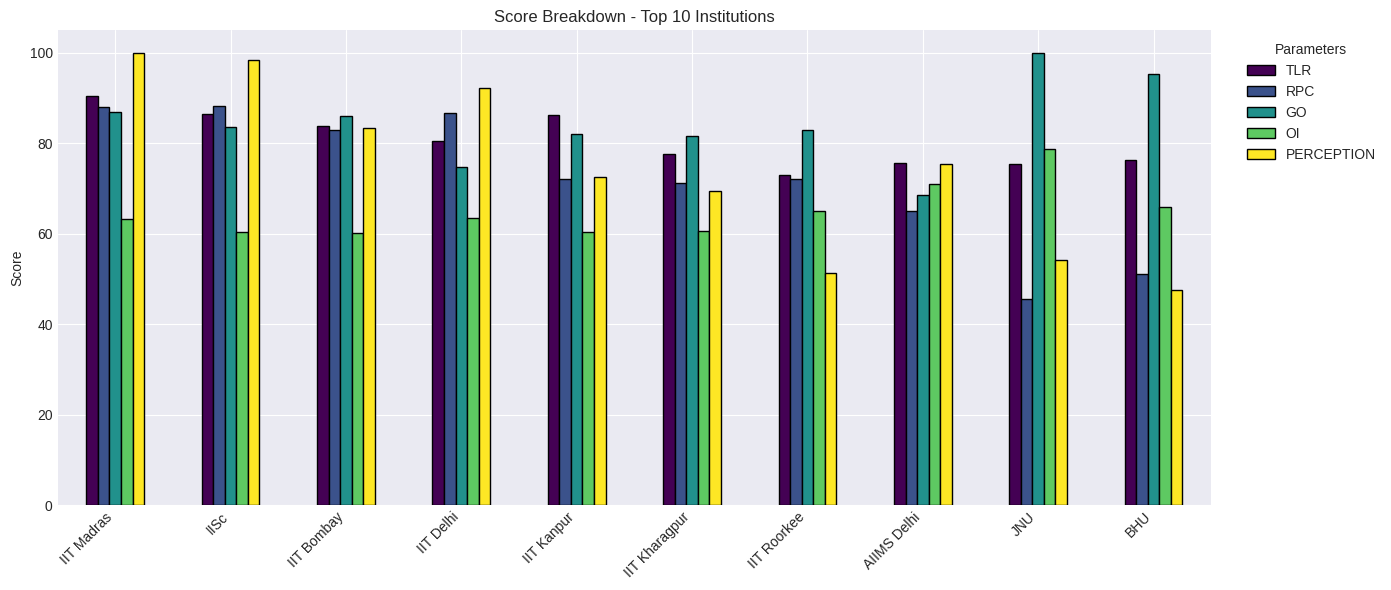

In [15]:
# Score breakdown for Top 10
top10_scores = df.head(10)[['Institute Name'] + score_cols].set_index('Institute Name')

# Shorten names for better display
top10_scores.index = ['IIT Madras', 'IISc', 'IIT Bombay', 'IIT Delhi', 'IIT Kanpur', 
                       'IIT Kharagpur', 'IIT Roorkee', 'AIIMS Delhi', 'JNU', 'BHU']

top10_scores.plot(kind='bar', figsize=(14, 6), colormap='viridis', edgecolor='black')
plt.title('Score Breakdown - Top 10 Institutions')
plt.ylabel('Score')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Parameters', bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

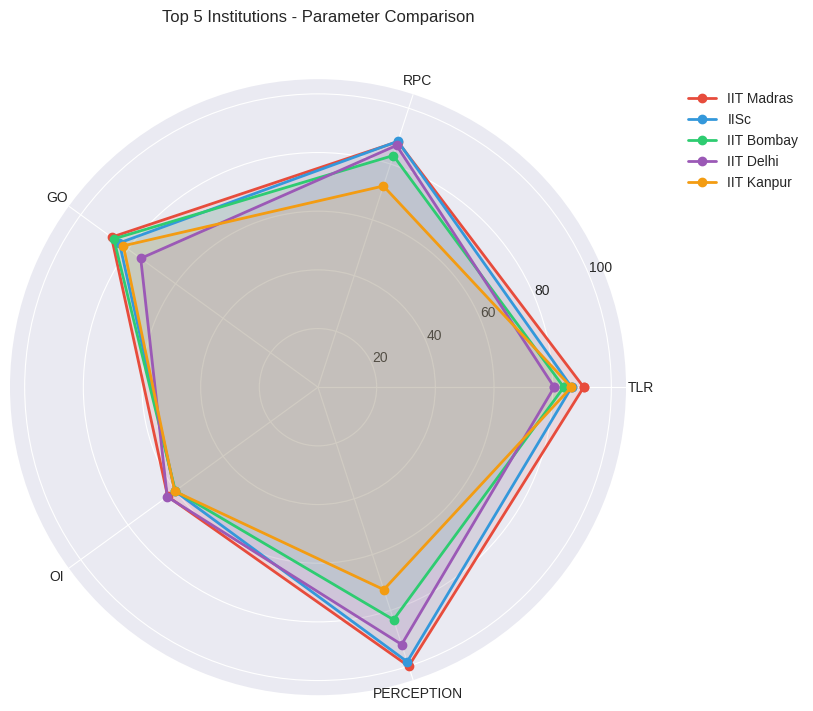

In [16]:
# Radar chart for Top 5
from math import pi

categories = score_cols
N = len(categories)

angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

colors = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6', '#f39c12']
labels = ['IIT Madras', 'IISc', 'IIT Bombay', 'IIT Delhi', 'IIT Kanpur']

for i in range(5):
    values = df.iloc[i][score_cols].values.flatten().tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=labels[i], color=colors[i])
    ax.fill(angles, values, alpha=0.1, color=colors[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)
ax.set_ylim(0, 105)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1))
plt.title('Top 5 Institutions - Parameter Comparison', y=1.08)
plt.show()

## 7. City-wise Analysis

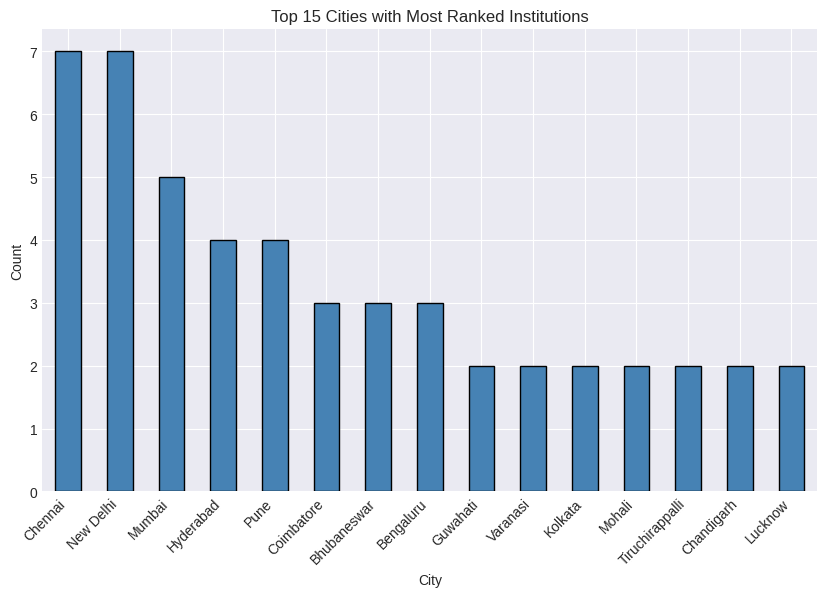

In [17]:
# Top cities by institution count
city_counts = df['City'].value_counts().head(15)

plt.figure(figsize=(10, 6))
city_counts.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Top 15 Cities with Most Ranked Institutions')
plt.xlabel('City')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.show()

## 8. IIT vs Non-IIT Comparison

In [18]:
# Identify IITs
df['Is_IIT'] = df['Institute Name'].str.contains('Indian Institute of Technology', case=False)

iit_comparison = df.groupby('Is_IIT')[score_cols + ['Score']].mean()
iit_comparison.index = ['Non-IIT', 'IIT']
iit_comparison

,TLR,RPC,GO,OI,PERCEPTION,Score
Non-IIT,68.483253,40.816747,74.693614,64.173253,20.235542,56.169880
IIT,72.822353,59.716471,75.381765,63.174706,43.768824,65.530588


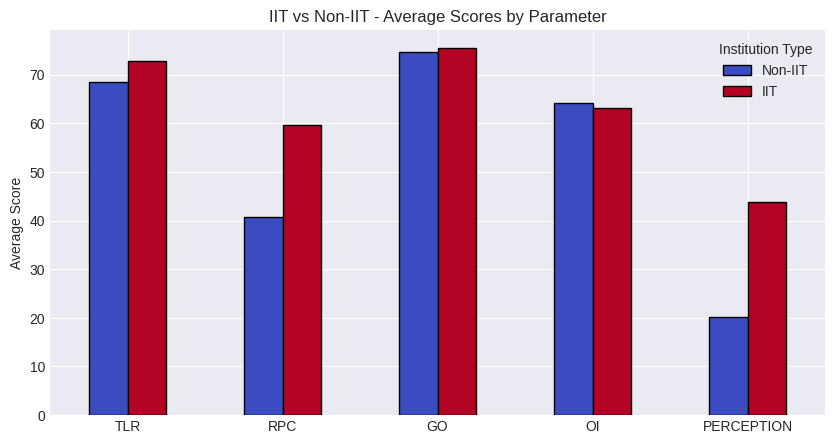

In [19]:
# Visual comparison
iit_comparison[score_cols].T.plot(kind='bar', figsize=(10, 5), colormap='coolwarm', edgecolor='black')
plt.title('IIT vs Non-IIT - Average Scores by Parameter')
plt.ylabel('Average Score')
plt.xticks(rotation=0)
plt.legend(title='Institution Type')
plt.show()

In [20]:
# Count of IITs in Top 100
print(f"Number of IITs in Top 100: {df['Is_IIT'].sum()}")
print(f"Number of Non-IITs: {(~df['Is_IIT']).sum()}")

Number of IITs in Top 100: 17
Number of Non-IITs: 83


## 9. Score vs Rank Relationship

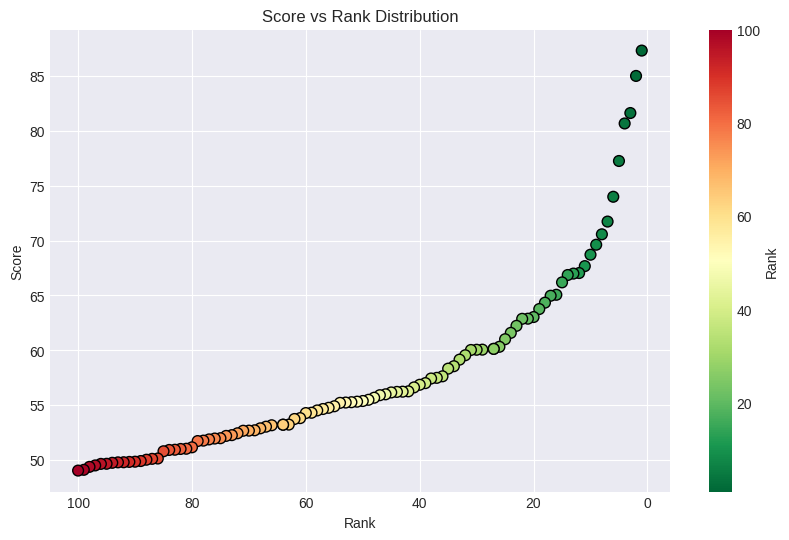

In [21]:
plt.figure(figsize=(10, 6))
plt.scatter(df['Rank'], df['Score'], c=df['Rank'], cmap='RdYlGn_r', s=60, edgecolor='black')
plt.colorbar(label='Rank')
plt.xlabel('Rank')
plt.ylabel('Score')
plt.title('Score vs Rank Distribution')
plt.gca().invert_xaxis()
plt.show()

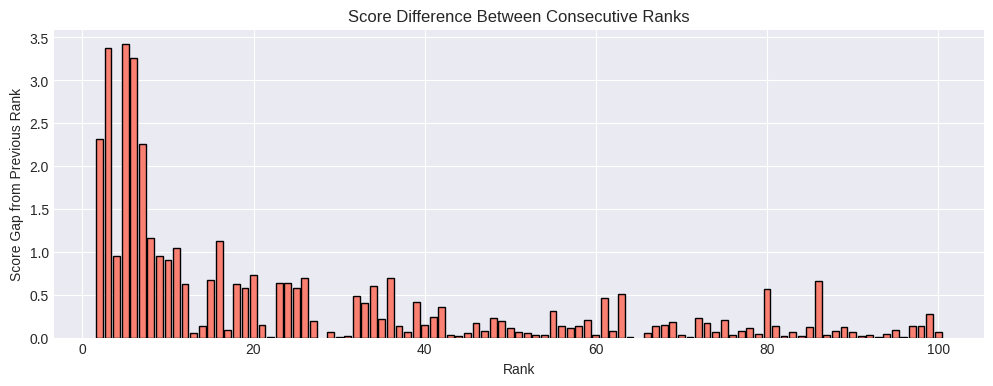

In [22]:
# Score gap between consecutive ranks
df['Score_Gap'] = df['Score'].diff().abs()

plt.figure(figsize=(12, 4))
plt.bar(df['Rank'][1:], df['Score_Gap'][1:], color='salmon', edgecolor='black')
plt.xlabel('Rank')
plt.ylabel('Score Gap from Previous Rank')
plt.title('Score Difference Between Consecutive Ranks')
plt.show()

## 10. Key Insights

In [23]:
print("="*60)
print("NIRF 2025 - KEY INSIGHTS")
print("="*60)

print(f"\n📊 Total Institutions: {len(df)}")
print(f"\n🏆 Top Institution: {df.iloc[0]['Institute Name']} (Score: {df.iloc[0]['Score']})")
print(f"\n📍 States Represented: {df['State'].nunique()}")
print(f"\n🏙️ Cities Represented: {df['City'].nunique()}")

print(f"\n--- Score Range ---")
print(f"   Highest: {df['Score'].max()}")
print(f"   Lowest: {df['Score'].min()}")
print(f"   Mean: {df['Score'].mean():.2f}")

print(f"\n--- Top States by Count ---")
for state, count in state_counts.head(5).items():
    print(f"   {state}: {count} institutions")

print(f"\n--- Parameter with Highest Correlation to Score ---")
best_param = score_corr.idxmax()
print(f"   {best_param}: {score_corr[best_param]:.3f}")

print(f"\n--- IIT Performance ---")
print(f"   IITs in Top 100: {df['Is_IIT'].sum()}")
print(f"   Avg IIT Score: {df[df['Is_IIT']]['Score'].mean():.2f}")
print(f"   Avg Non-IIT Score: {df[~df['Is_IIT']]['Score'].mean():.2f}")

NIRF 2025 - KEY INSIGHTS

📊 Total Institutions: 100

🏆 Top Institution: Indian Institute of Technology Madras (Score: 87.31)

📍 States Represented: 22

🏙️ Cities Represented: 62

--- Score Range ---
   Highest: 87.31
   Lowest: 49.04
   Mean: 57.76

--- Top States by Count ---
   Tamil Nadu: 17 institutions
   Maharashtra: 11 institutions
   Uttar Pradesh: 9 institutions
   Delhi: 8 institutions
   Karnataka: 6 institutions

--- Parameter with Highest Correlation to Score ---
   RPC: 0.888

--- IIT Performance ---
   IITs in Top 100: 17
   Avg IIT Score: 65.53
   Avg Non-IIT Score: 56.17
